In [2]:
#Импортирование ключеввых библиотек
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

длина чашелист.     float64
ширина чашелист.    float64
длина лепест.       float64
ширина лепест.      float64
класс                   str
dtype: object
     длина чашелист.  ширина чашелист.  длина лепест.  ширина лепест.  \
114              5.8               2.8            5.1             2.4   
62               6.0               2.2            4.0             1.0   
33               5.5               4.2            1.4             0.2   
107              7.3               2.9            6.3             1.8   
7                5.0               3.4            1.5             0.2   
100              6.3               3.3            6.0             2.5   
40               5.0               3.5            1.3             0.3   
86               6.7               3.1            4.7             1.5   
76               6.8               2.8            4.8             1.4   
71               6.1               2.8            4.0             1.3   

               класс  
114   Iris-virginic

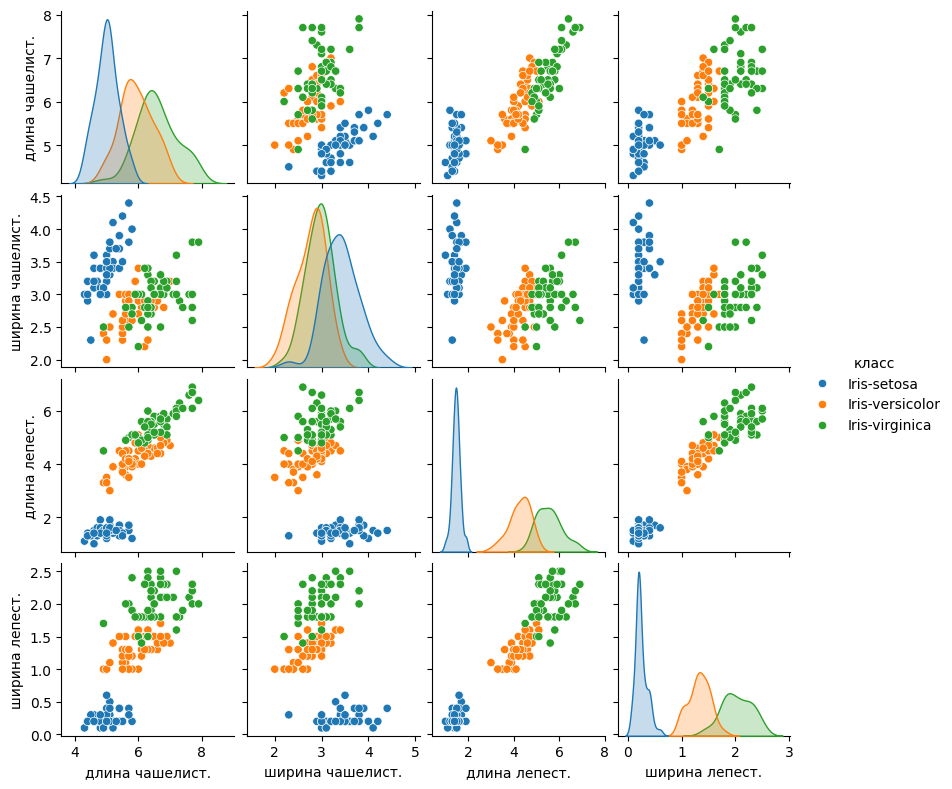

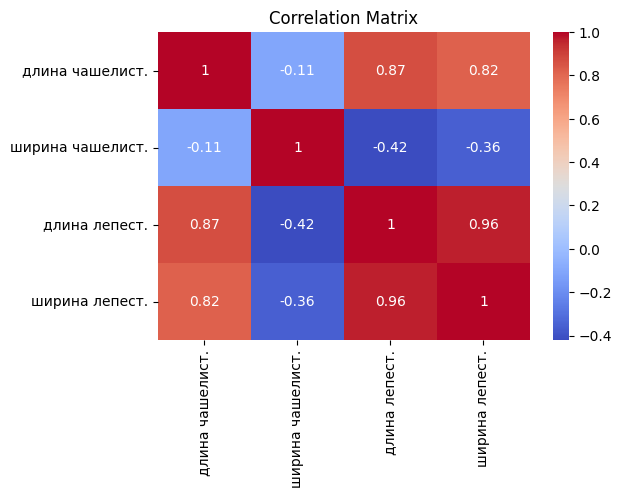

In [8]:
#Импортирование и просмотр дата_сета, и его структуры и визуализация
dataset = pd.read_csv('https://raw.githubusercontent.com/andriygav/MachineLearningSeminars/master/sem1/data/iris.csv', 
                      header=None, 
                      names=['длина чашелист.', 'ширина чашелист.', 
                             'длина лепест.', 'ширина лепест.', 'класс'])

#Сведения о исходном датасете
print(dataset.dtypes)
print(dataset.sample(10, random_state=0))

#Визуализация связи между классами и признаками
sns.pairplot(dataset, hue='класс', height=2)
plt.show()

#Кореляции между признаками
plt.figure(figsize=(6,4))
sns.heatmap(dataset.drop(columns=['класс']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()



In [4]:
#Предобработка данных дата_сета
binary_dataset = dataset.drop(index=dataset.index[dataset['класс'] == 'Iris-setosa'])
binary_dataset["класс"] = (binary_dataset["класс"] == "Iris-virginica").astype(int) * 2 - 1
Y = binary_dataset["класс"] #множество допустимых обьектов
X = binary_dataset.drop(columns=["класс"]) #множество признаков (признаковое пространство)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
print(X_train)

     длина чашелист.  ширина чашелист.  длина лепест.  ширина лепест.
65               6.7               3.1            4.4             1.4
102              7.1               3.0            5.9             2.1
110              6.5               3.2            5.1             2.0
116              6.5               3.0            5.5             1.8
118              7.7               2.6            6.9             2.3
..               ...               ...            ...             ...
67               5.8               2.7            4.1             1.0
86               6.7               3.1            4.7             1.5
135              7.7               3.0            6.1             2.3
71               6.1               2.8            4.0             1.3
75               6.6               3.0            4.4             1.4

[80 rows x 4 columns]


In [5]:
#Обучение модели, вывод параметров
model = LogisticRegression(random_state=0, max_iter=2000, stratify=Y)
model.fit(X_train, Y_train)
print("weights:", model.coef_)
print("bias:", model.intercept_)

[[-0.00982694 -0.22298575  2.6149747   2.34577828]]
[-16.11042558]


In [6]:
#Тестирование модели
Y_predict = model.predict(X_test)

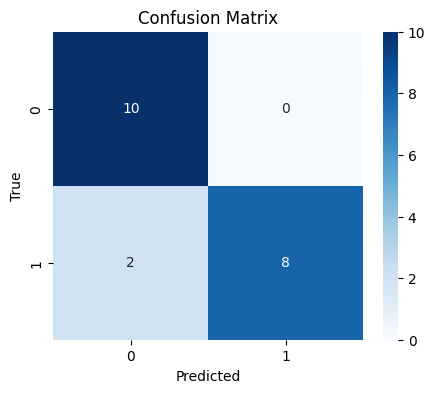

              precision    recall  f1-score   support

          -1       0.83      1.00      0.91        10
           1       1.00      0.80      0.89        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20

train accuracy: 0.95
test accuracy: 0.9


In [10]:
#Оценка качества модели и визуализация

#Основные метрики и визуализация
cm = confusion_matrix(Y_test, Y_predict)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
print(classification_report(Y_test, Y_predict))

#Визуализация ERM на тестовой и тренировочной выборке
print("train accuracy:", model.score(X_train, Y_train))
print("test accuracy:", model.score(X_test, Y_test))